In [1]:
import pandas as pd
from pathlib import Path
import os
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns

from torch_geometric.datasets import TUDataset
from torch_geometric.transforms import NormalizeFeatures    

/Users/toanly/Main/Class/Deep Learning/CS-5137-Deep-Learning/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Load dataset

In [2]:
data = "ENZYMES"
ROOT_DIR = Path.cwd().parent
DATA_DIR = ROOT_DIR / f"data/{data}"

In [3]:
adj_mat = np.loadtxt(DATA_DIR / f'{data}_A.txt', delimiter=',', dtype=int)
graph_indicator = np.loadtxt(DATA_DIR / f'{data}_graph_indicator.txt', dtype=int)
graph_labels = np.loadtxt(DATA_DIR / f'{data}_graph_labels.txt', dtype=int)
node_attributes = np.loadtxt(DATA_DIR / f'{data}_node_attributes.txt', delimiter=',')
node_labels = np.loadtxt(DATA_DIR / f'{data}_node_labels.txt', dtype=int)

# Shape

In [4]:
print(f'Adjacency Matrix Shape: {adj_mat.shape}')
print(f'Graph Indicator Shape: {graph_indicator.shape}')
print(f'Graph Labels Shape: {graph_labels.shape}')
print(f'Node Attributes Shape: {node_attributes.shape}')
print(f'Node Labels Shape: {node_labels.shape}')

Adjacency Matrix Shape: (74564, 2)
Graph Indicator Shape: (19580,)
Graph Labels Shape: (600,)
Node Attributes Shape: (19580, 18)
Node Labels Shape: (19580,)


### Adjacency Matrix

In [5]:
adj_mat

array([[    2,     1],
       [    3,     1],
       [    4,     1],
       ...,
       [19557, 19580],
       [19562, 19580],
       [19563, 19580]], shape=(74564, 2))

Adjacency Matrix shape: (74564, 2) \
=> Total number of edges across the entire dataset = 74,564


### Graph Indicator

In [6]:
graph_indicator

array([  1,   1,   1, ..., 600, 600, 600], shape=(19580,))

Graph Indicator shape: (19580,) \
=> Total nodes across all graphs = 19580

It tells which graph that each node belongs to


### Graph Labels

In [7]:
graph_labels

array([6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
       6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
       6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
       6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
       6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
       5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
       5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
       5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
       5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
       5, 5, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2,

Graph Labels shape: (600,) \
=> Total graphs = 600

Each graph has 1 label, which is what we're trying to classify

In [19]:
np.unique(graph_labels)

array([1, 2, 3, 4, 5, 6])

### Node Attributes

In [8]:
node_attributes

array([[11.      , 15.887014, 37.78    , ...,  3.      ,  6.      ,
         2.      ],
       [11.      , 16.362935, 40.38    , ...,  1.      ,  8.      ,
         2.      ],
       [16.      , 21.395072, 63.35    , ...,  2.      ,  7.      ,
         7.      ],
       ...,
       [ 4.      , 10.237717, 20.7     , ...,  0.      ,  2.      ,
         2.      ],
       [ 6.      , 16.454257, 23.03    , ...,  1.      ,  3.      ,
         2.      ],
       [ 6.      , 16.962735, 29.16    , ...,  0.      ,  2.      ,
         4.      ]], shape=(19580, 18))

Node Attributes shape: (19580, 18) \
=> 19580 nodes, each node is a 18-dimensional feature vector

### Node Labels

In [9]:
node_labels

array([1, 1, 1, ..., 2, 2, 2], shape=(19580,))

Node Labels shape: (19580,) \
=> 19580 nodes -> 19580 labels

In [10]:
np.unique(node_labels)

array([1, 2, 3])

# EDA

### Group nodes

In [11]:
graphs = defaultdict(list)
for node_id, graph_id in enumerate(graph_indicator, start=1):
    graphs[graph_id].append(node_id)

len(graphs)

600

In [12]:
for graph_id, nodes in list(graphs.items())[:10]:
    print(f'Number of nodes in graph {graph_id}: {len(nodes)}')

Number of nodes in graph 1: 37
Number of nodes in graph 2: 23
Number of nodes in graph 3: 25
Number of nodes in graph 4: 24
Number of nodes in graph 5: 23
Number of nodes in graph 6: 24
Number of nodes in graph 7: 26
Number of nodes in graph 8: 88
Number of nodes in graph 9: 23
Number of nodes in graph 10: 32


In [13]:
total_nodes = sum(len(nodes) for nodes in graphs.values())
print(f'Total number of nodes across all graphs: {total_nodes}')

Total number of nodes across all graphs: 19580


### Group edges

In [14]:
graph_edges = defaultdict(list)
for src, dst in adj_mat:
    graph_id = graph_indicator[src - 1]
    graph_edges[graph_id].append((src, dst))

for graph_id, edges in list(graph_edges.items())[:10]:
    print(f'Number of edges in graph {graph_id}: {len(edges)}')

Number of edges in graph 1: 168
Number of edges in graph 2: 102
Number of edges in graph 3: 92
Number of edges in graph 4: 90
Number of edges in graph 5: 90
Number of edges in graph 6: 92
Number of edges in graph 7: 118
Number of edges in graph 8: 266
Number of edges in graph 9: 78
Number of edges in graph 10: 106


## Some Graph Statistics

### Node Distribution

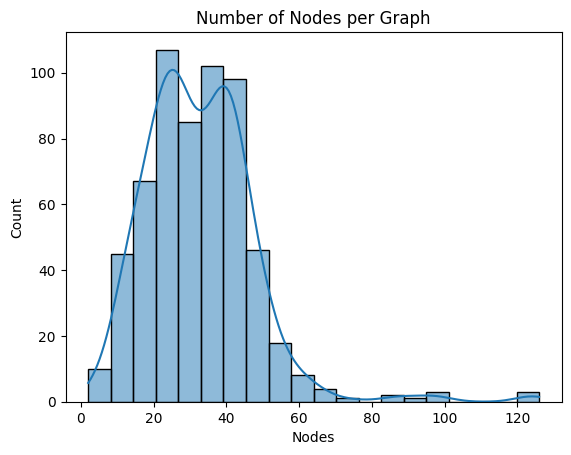

In [15]:
num_nodes = [len(graphs[i]) for i in range(1, len(graph_labels)+1)]

sns.histplot(num_nodes, bins=20, kde=True)
plt.title("Number of Nodes per Graph")
plt.xlabel("Nodes")
plt.ylabel("Count")
plt.show()

### Edge Distribution

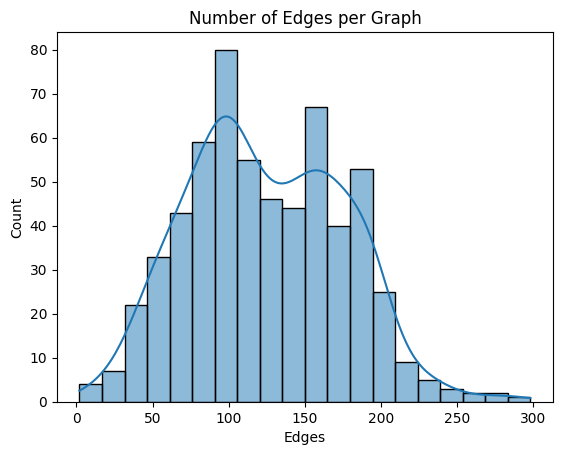

In [16]:
num_edges = [len(graph_edges[i]) for i in range(1, len(graph_labels)+1)]

sns.histplot(num_edges, bins=20, kde=True)
plt.title("Number of Edges per Graph")
plt.xlabel("Edges")
plt.ylabel("Count")
plt.show()

### Class Distribution

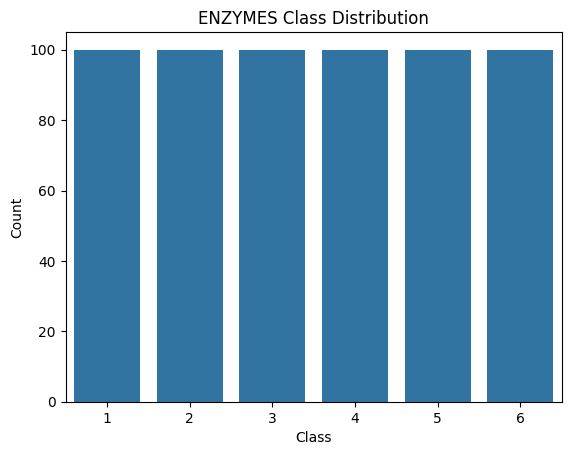

In [17]:
sns.countplot(x=graph_labels)
plt.title("ENZYMES Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

### Node Label Distribution

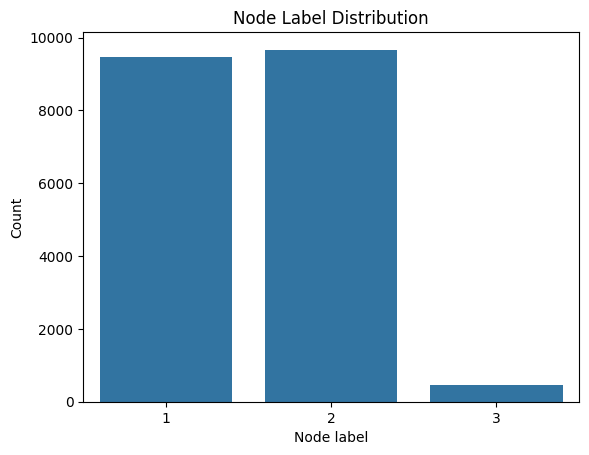

In [18]:
sns.countplot(x=node_labels)
plt.title("Node Label Distribution")
plt.xlabel("Node label")
plt.ylabel("Count")
plt.show()